In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

covid = pd.read_csv("covid_19_india.csv")
vaccine = pd.read_csv("covid_vaccine_statewise.csv")
testing = pd.read_csv("StatewiseTestingDetails.csv")


In [13]:
print("Describe:",covid.info())

print("Describe:",covid.shape)

print("Describe:",covid.describe())

covid.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Sno                       18110 non-null  int64 
 1   Date                      18110 non-null  object
 2   Time                      18110 non-null  object
 3   State/UnionTerritory      18110 non-null  object
 4   ConfirmedIndianNational   18110 non-null  object
 5   ConfirmedForeignNational  18110 non-null  object
 6   Cured                     18110 non-null  int64 
 7   Deaths                    18110 non-null  int64 
 8   Confirmed                 18110 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.2+ MB
Describe: None
Describe: (18110, 9)
Describe:                 Sno         Cured         Deaths     Confirmed
count  18110.000000  1.811000e+04   18110.000000  1.811000e+04
mean    9055.500000  2.786375e+05    4052.402264  3.010314e+05
std     5228.

Sno                         0
Date                        0
Time                        0
State/UnionTerritory        0
ConfirmedIndianNational     0
ConfirmedForeignNational    0
Cured                       0
Deaths                      0
Confirmed                   0
dtype: int64

In [14]:
print("Describe:",vaccine.info())

print("Describe:",vaccine.shape)

print("Describe:",vaccine.describe())

vaccine.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7845 entries, 0 to 7844
Data columns (total 24 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Updated On                           7845 non-null   object 
 1   State                                7845 non-null   object 
 2   Total Doses Administered             7621 non-null   float64
 3   Sessions                             7621 non-null   float64
 4    Sites                               7621 non-null   float64
 5   First Dose Administered              7621 non-null   float64
 6   Second Dose Administered             7621 non-null   float64
 7   Male (Doses Administered)            7461 non-null   float64
 8   Female (Doses Administered)          7461 non-null   float64
 9   Transgender (Doses Administered)     7461 non-null   float64
 10   Covaxin (Doses Administered)        7621 non-null   float64
 11  CoviShield (Doses Administered

Updated On                                0
State                                     0
Total Doses Administered                224
Sessions                                224
 Sites                                  224
First Dose Administered                 224
Second Dose Administered                224
Male (Doses Administered)               384
Female (Doses Administered)             384
Transgender (Doses Administered)        384
 Covaxin (Doses Administered)           224
CoviShield (Doses Administered)         224
Sputnik V (Doses Administered)         4850
AEFI                                   2407
18-44 Years (Doses Administered)       6143
45-60 Years (Doses Administered)       6143
60+ Years (Doses Administered)         6143
18-44 Years(Individuals Vaccinated)    4112
45-60 Years(Individuals Vaccinated)    4111
60+ Years(Individuals Vaccinated)      4111
Male(Individuals Vaccinated)           7685
Female(Individuals Vaccinated)         7685
Transgender(Individuals Vaccinat

In [15]:
print("Describe:",testing.info())

print("Describe:",testing.shape)

print("Describe:",testing.describe())

testing.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16336 entries, 0 to 16335
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          16336 non-null  object 
 1   State         16336 non-null  object 
 2   TotalSamples  16336 non-null  float64
 3   Negative      6969 non-null   object 
 4   Positive      5662 non-null   float64
dtypes: float64(2), object(3)
memory usage: 638.3+ KB
Describe: None
Describe: (16336, 5)
Describe:        TotalSamples      Positive
count  1.633600e+04  5.662000e+03
mean   5.376466e+06  5.652654e+04
std    8.780338e+06  1.673108e+05
min    5.800000e+01  0.000000e+00
25%    1.729098e+05  5.362500e+02
50%    9.307580e+05  4.771000e+03
75%    7.284795e+06  3.361875e+04
max    6.789786e+07  1.638961e+06


Date                0
State               0
TotalSamples        0
Negative         9367
Positive        10674
dtype: int64

## Converting Date Columns

In [16]:
covid['Date'] = pd.to_datetime(covid['Date'])

vaccine['Updated On'] = pd.to_datetime(
    vaccine['Updated On'],
    dayfirst=True
)

testing['Date'] = pd.to_datetime(testing['Date'])

## Handling Missing Values

In [17]:
vaccine.isnull().sum().sort_values(ascending=False)

Male(Individuals Vaccinated)           7685
Female(Individuals Vaccinated)         7685
Transgender(Individuals Vaccinated)    7685
18-44 Years (Doses Administered)       6143
45-60 Years (Doses Administered)       6143
60+ Years (Doses Administered)         6143
Sputnik V (Doses Administered)         4850
18-44 Years(Individuals Vaccinated)    4112
60+ Years(Individuals Vaccinated)      4111
45-60 Years(Individuals Vaccinated)    4111
AEFI                                   2407
Total Individuals Vaccinated           1926
Female (Doses Administered)             384
Transgender (Doses Administered)        384
Male (Doses Administered)               384
Sessions                                224
Total Doses Administered                224
 Sites                                  224
Second Dose Administered                224
First Dose Administered                 224
 Covaxin (Doses Administered)           224
CoviShield (Doses Administered)         224
State                           

In [18]:
num_cols = vaccine.select_dtypes(include=np.number).columns

vaccine[num_cols] = vaccine[num_cols].fillna(0)

In [19]:
testing['Negative'] = testing['Negative'].fillna(0)
testing['Positive'] = testing['Positive'].fillna(0)

In [20]:
testing['Negative'] = pd.to_numeric(
    testing['Negative'],
    errors='coerce'
)

testing['Positive'] = pd.to_numeric(
    testing['Positive'],
    errors='coerce'
)

# Univariate Analysis

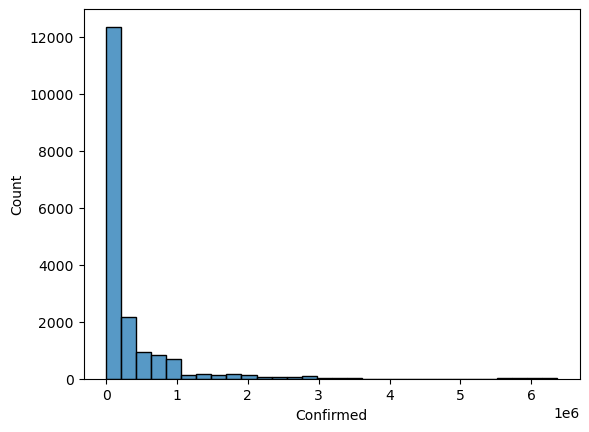

In [21]:
sns.histplot(covid['Confirmed'], bins=30)
plt.show()

# Interpretation:

Highly right-skewed
Few states have very high cases

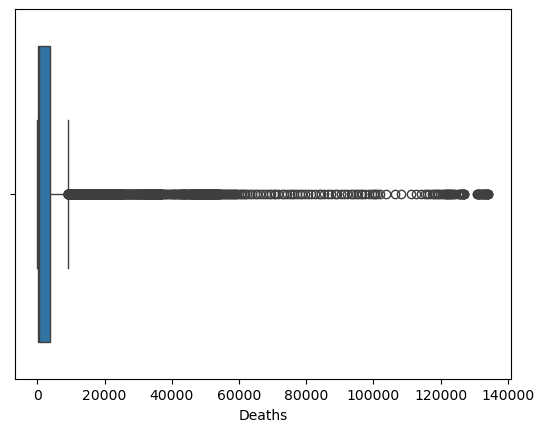

In [22]:
sns.boxplot(x=covid['Deaths'])
plt.show()

# Interpretation:

- Many outliers
- Some states experienced very high mortality

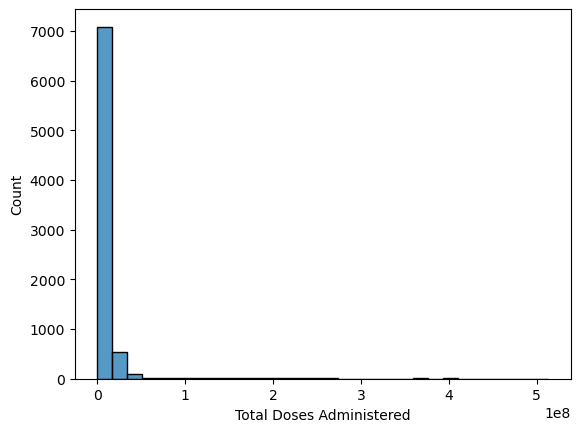

In [24]:
sns.histplot(
    vaccine['Total Doses Administered'],
    bins=30
)
plt.show()

# Bivariate Analysis

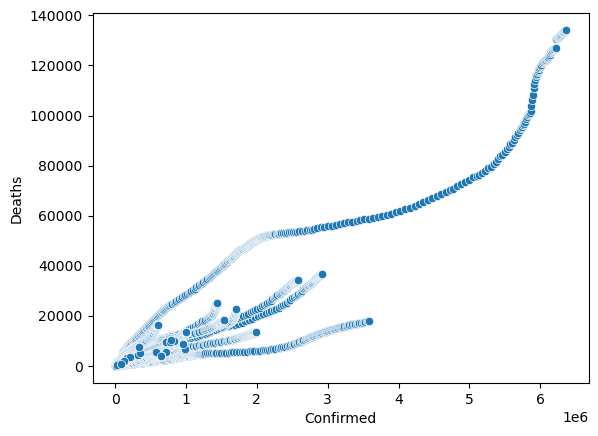

In [25]:
sns.scatterplot(
    data=covid,
    x='Confirmed',
    y='Deaths'
)
plt.show()

## Interpretation:

Strong positive relationship

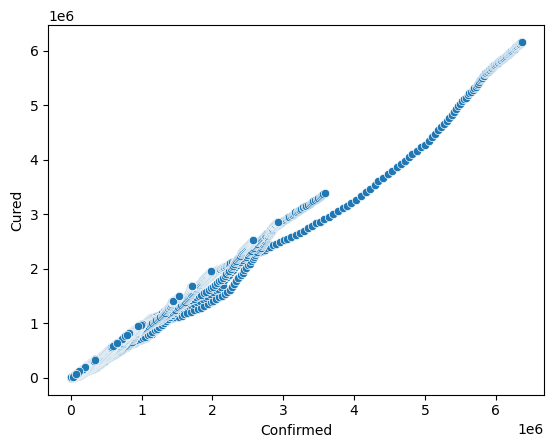

In [26]:
sns.scatterplot(
    data=covid,
    x='Confirmed',
    y='Cured'
)
plt.show()

## Interpretation:

Higher confirmed cases usually mean higher recoverie

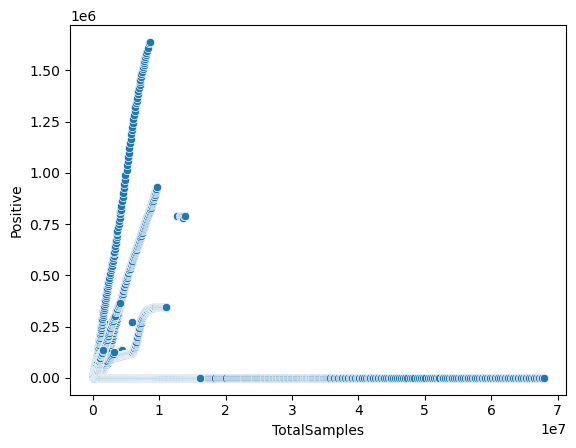

In [27]:
sns.scatterplot(
    data=testing,
    x='TotalSamples',
    y='Positive'
)
plt.show()

## Interpretation:

States conducting more tests identify more positive cases

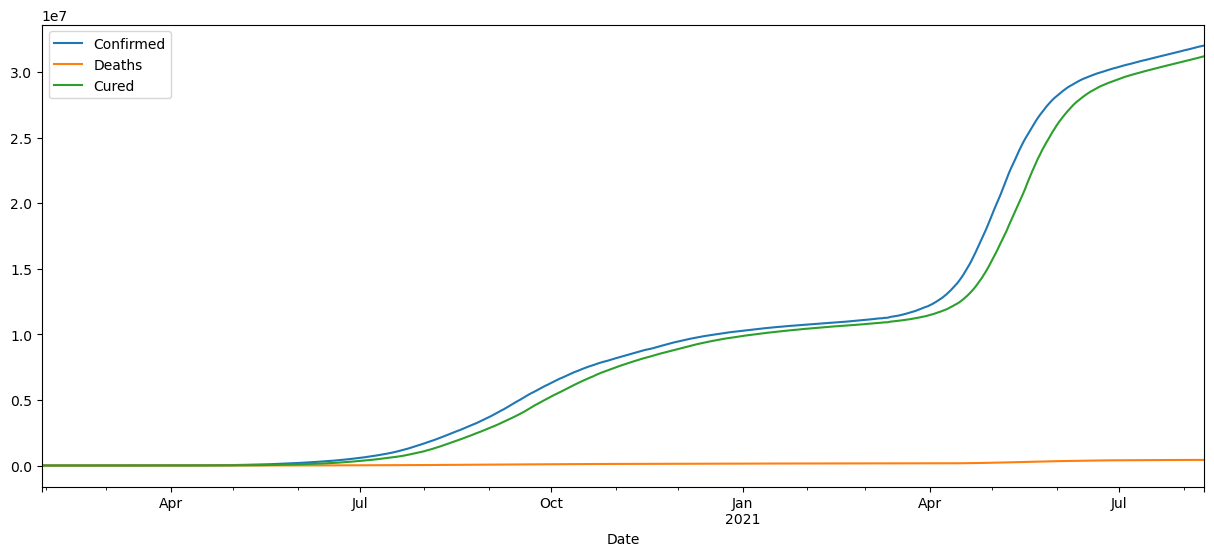

In [28]:
daily = covid.groupby('Date')[
    ['Confirmed','Deaths','Cured']
].sum()

daily.plot(figsize=(15,6))
plt.show()

## Interpretation:

- First wave
- Second wave spike

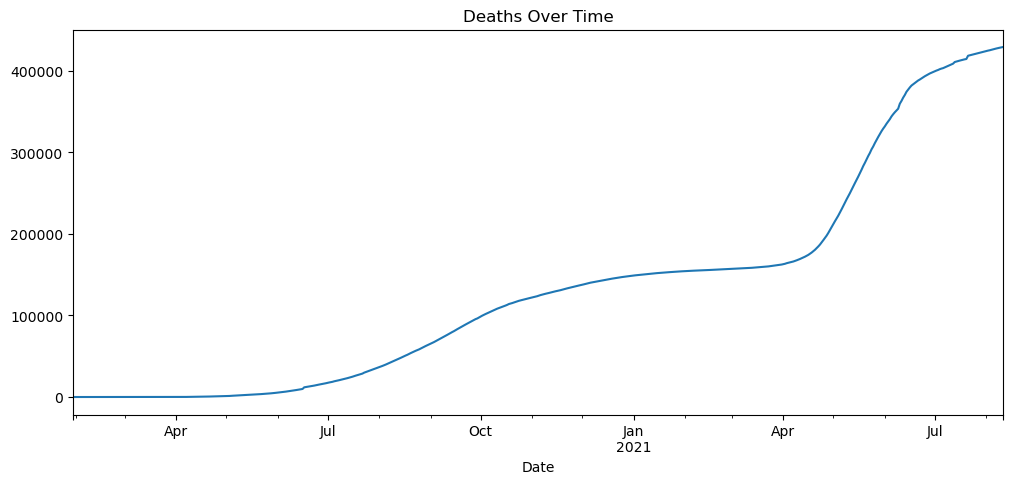

In [29]:
daily['Deaths'].plot(figsize=(12,5))
plt.title("Deaths Over Time")
plt.show()

# State-wise Analysis

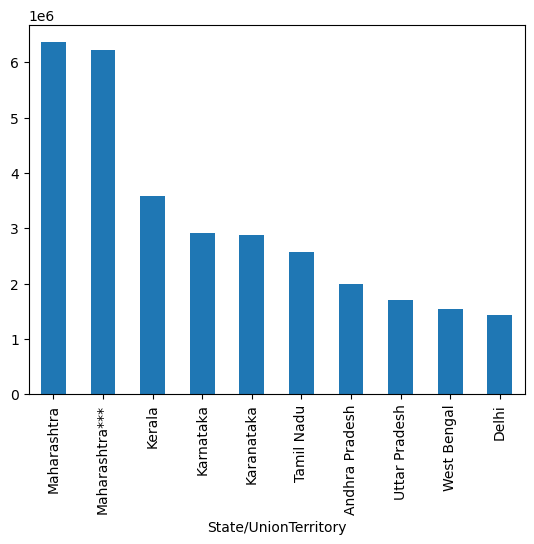

In [30]:
latest = covid.groupby(
    'State/UnionTerritory'
)['Confirmed'].max()

latest.sort_values(
    ascending=False
).head(10).plot(
    kind='bar'
)

plt.show()

In [31]:
covid['State/UnionTerritory'].unique()

array(['Kerala', 'Telengana', 'Delhi', 'Rajasthan', 'Uttar Pradesh',
       'Haryana', 'Ladakh', 'Tamil Nadu', 'Karnataka', 'Maharashtra',
       'Punjab', 'Jammu and Kashmir', 'Andhra Pradesh', 'Uttarakhand',
       'Odisha', 'Puducherry', 'West Bengal', 'Chhattisgarh',
       'Chandigarh', 'Gujarat', 'Himachal Pradesh', 'Madhya Pradesh',
       'Bihar', 'Manipur', 'Mizoram', 'Andaman and Nicobar Islands',
       'Goa', 'Unassigned', 'Assam', 'Jharkhand', 'Arunachal Pradesh',
       'Tripura', 'Nagaland', 'Meghalaya',
       'Dadra and Nagar Haveli and Daman and Diu',
       'Cases being reassigned to states', 'Sikkim', 'Daman & Diu',
       'Lakshadweep', 'Telangana', 'Dadra and Nagar Haveli', 'Bihar****',
       'Madhya Pradesh***', 'Himanchal Pradesh', 'Karanataka',
       'Maharashtra***'], dtype=object)

In [32]:
covid['State/UnionTerritory'] = (
    covid['State/UnionTerritory']
    .str.replace(r'\*+', '', regex=True)
    .str.strip()
)

In [33]:
covid['State/UnionTerritory'] = covid['State/UnionTerritory'].replace({
    'Telengana': 'Telangana',
    'Karanataka': 'Karnataka',
    'Himanchal Pradesh': 'Himachal Pradesh',
    'Daman & Diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'Dadra and Nagar Haveli': 'Dadra and Nagar Haveli and Daman and Diu'
})

In [34]:
covid = covid[
    ~covid['State/UnionTerritory'].isin([
        'Unassigned',
        'Cases being reassigned to states'
    ])
]

In [35]:
sorted(covid['State/UnionTerritory'].unique())

['Andaman and Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh',
 'Dadra and Nagar Haveli and Daman and Diu',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jammu and Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Ladakh',
 'Lakshadweep',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'Odisha',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'Tripura',
 'Uttar Pradesh',
 'Uttarakhand',
 'West Bengal']

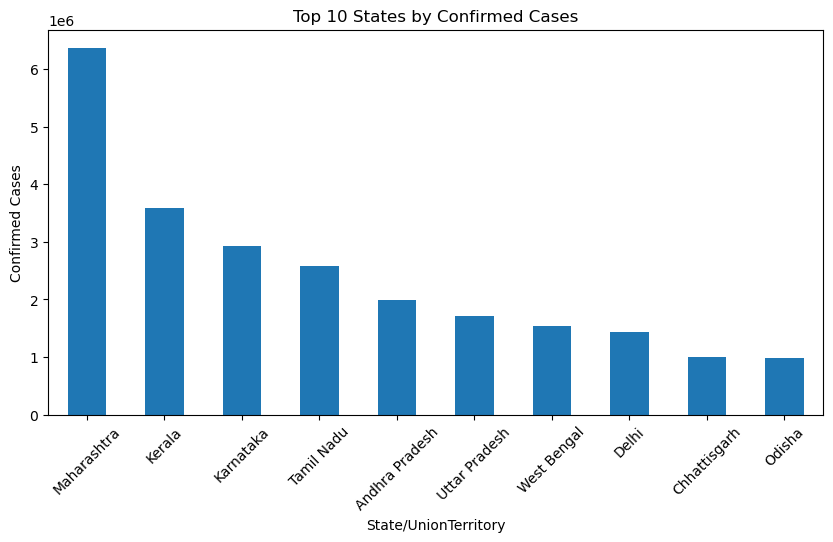

In [36]:
latest = covid.groupby(
    'State/UnionTerritory'
)['Confirmed'].max()

top10 = latest.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
top10.plot(kind='bar')
plt.title('Top 10 States by Confirmed Cases')
plt.ylabel('Confirmed Cases')
plt.xticks(rotation=45)
plt.show()

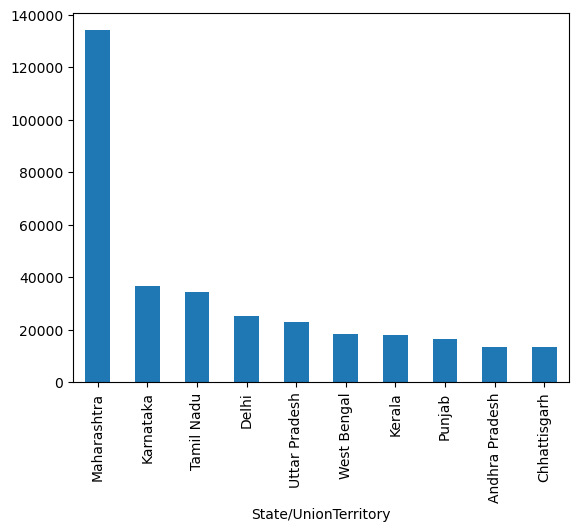

In [37]:
covid.groupby(
    'State/UnionTerritory'
)['Deaths'].max().sort_values(
    ascending=False
).head(10).plot(
    kind='bar'
)
plt.show()

# Correlation Analysis

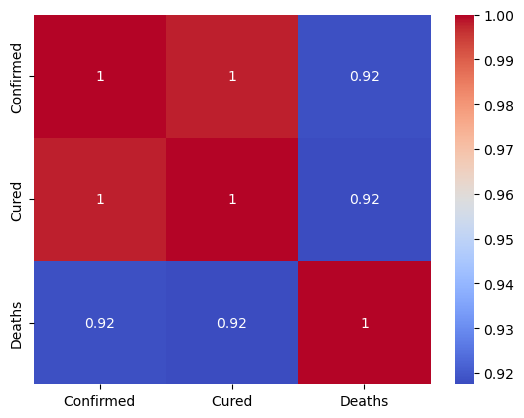

In [38]:
numeric_cols = [
    'Confirmed',
    'Cured',
    'Deaths'
]

sns.heatmap(
    covid[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

 # Interpretation:

Strong correlation among all variables

# Active Cases

In [39]:
covid['ActiveCases'] = (
    covid['Confirmed']
    - covid['Cured']
    - covid['Deaths']
)

# Recovery Rate

In [40]:
covid['RecoveryRate'] = (
    covid['Cured']
    / covid['Confirmed']
) * 100

# Death Rate

In [41]:
covid['DeathRate'] = (
    covid['Deaths']
    / covid['Confirmed']
) * 100

# Positivity Rate

In [42]:
testing['PositivityRate'] = (
    testing['Positive']
    / testing['TotalSamples']
) * 100

# Vaccination Efficiency

In [43]:
vaccine['SecondDoseRatio'] = (
    vaccine['Second Dose Administered']
    / vaccine['First Dose Administered']
) * 100

# Year , month , Quater and Day of week

In [44]:
covid['Year'] = covid['Date'].dt.year

covid['Month'] = covid['Date'].dt.month

covid['Quarter'] = covid['Date'].dt.quarter

covid['DayOfWeek'] = covid['Date'].dt.day_name()

# Daily New Cases

In [45]:
covid = covid.sort_values(
    ['State/UnionTerritory','Date']
)

covid['DailyNewCases'] = (
    covid.groupby(
        'State/UnionTerritory'
    )['Confirmed']
    .diff()
)

# Daily New Deaths

In [46]:
covid['DailyNewDeaths'] = (
    covid.groupby(
        'State/UnionTerritory'
    )['Deaths']
    .diff()
)

# Daily Recoveries

In [48]:
covid['DailyRecoveries'] = (
    covid.groupby(
        'State/UnionTerritory'
    )['Cured']
    .diff()
)

# Multivariate Analysis

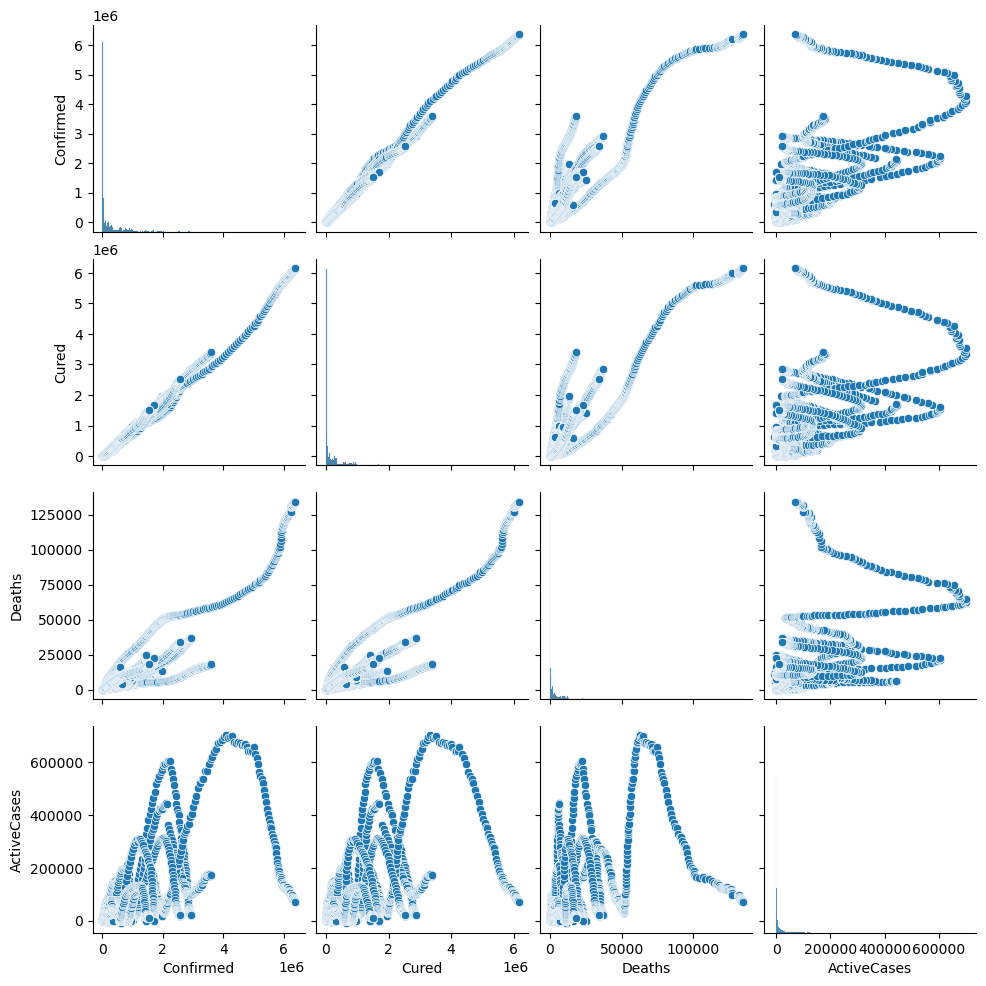

In [49]:
sns.pairplot(
    covid[
        ['Confirmed',
         'Cured',
         'Deaths',
         'ActiveCases']
    ]
)

plt.show()

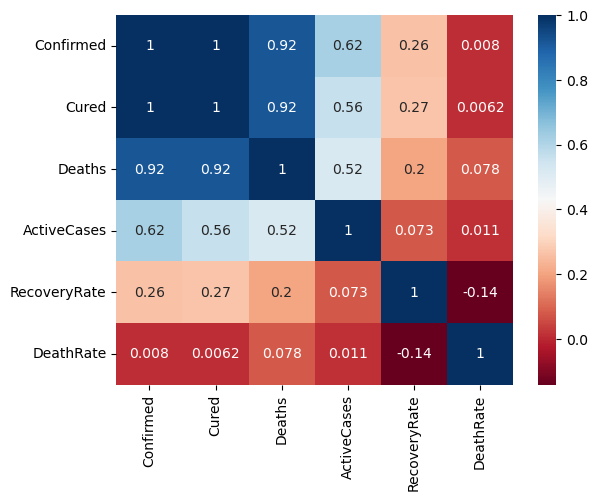

In [50]:
features = [
    'Confirmed',
    'Cured',
    'Deaths',
    'ActiveCases',
    'RecoveryRate',
    'DeathRate'
]

sns.heatmap(
    covid[features].corr(),
    annot=True,
    cmap='RdBu'
)
plt.show()

# 1. Which State Controlled COVID Best?

In [51]:
covid['RecoveryRate'] = (
    covid['Cured'] / covid['Confirmed']
) * 100

covid['DeathRate'] = (
    covid['Deaths'] / covid['Confirmed']
) * 100

In [52]:
latest_date = covid['Date'].max()

latest = covid[covid['Date'] == latest_date]

In [53]:
latest.head()

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed,ActiveCases,RecoveryRate,DeathRate,Year,Month,Quarter,DayOfWeek,DailyNewCases,DailyNewDeaths,DailyRecoveries
18074,18075,2021-08-11,8:00 AM,Andaman and Nicobar Islands,-,-,7412,129,7548,7,98.198198,1.709062,2021,8,3,Wednesday,2.0,0.0,0.0
18075,18076,2021-08-11,8:00 AM,Andhra Pradesh,-,-,1952736,13564,1985182,18882,98.365591,0.683262,2021,8,3,Wednesday,1461.0,15.0,2113.0
18076,18077,2021-08-11,8:00 AM,Arunachal Pradesh,-,-,47821,248,50605,2536,94.498567,0.490070,2021,8,3,Wednesday,233.0,2.0,301.0
18077,18078,2021-08-11,8:00 AM,Assam,-,-,559684,5420,576149,11045,97.142232,0.940729,2021,8,3,Wednesday,929.0,16.0,964.0
18078,18079,2021-08-11,8:00 AM,Bihar,-,-,715352,9646,725279,281,98.631285,1.329971,2021,8,3,Wednesday,44.0,0.0,49.0


In [54]:
latest[['State/UnionTerritory','RecoveryRate']]\
.sort_values(by='RecoveryRate', ascending=False)\
.head(10)

,State/UnionTerritory,RecoveryRate
18081,Dadra and Nagar Haveli and Daman and Diu,99.924911
18092,Lakshadweep,99.045114
18102,Rajasthan,99.040626
18084,Gujarat,98.753704
18085,Haryana,98.659419
18093,Madhya Pradesh,98.655269
18079,Chandigarh,98.641760
18108,Uttar Pradesh,98.635309
18078,Bihar,98.631285
18091,Ladakh,98.623291


In [55]:
best_recovery = latest.loc[
    latest['RecoveryRate'].idxmax()
]

print("State:", best_recovery['State/UnionTerritory'])
print("Recovery Rate:", round(best_recovery['RecoveryRate'],2), "%")

State: Dadra and Nagar Haveli and Daman and Diu
Recovery Rate: 99.92 %


In [56]:
latest[['State/UnionTerritory','DeathRate']]\
.sort_values(by='DeathRate', ascending=True)\
.head(10)

,State/UnionTerritory,DeathRate
18081,Dadra and Nagar Haveli and Daman and Diu,0.037545
18097,Mizoram,0.369171
18076,Arunachal Pradesh,0.490070
18092,Lakshadweep,0.496931
18090,Kerala,0.501967
18105,Telangana,0.589065
18099,Odisha,0.663804
18075,Andhra Pradesh,0.683262
18102,Rajasthan,0.938721
18077,Assam,0.940729


In [57]:
lowest_death = latest.loc[
    latest['DeathRate'].idxmin()
]

print("State:", lowest_death['State/UnionTerritory'])
print("Death Rate:", round(lowest_death['DeathRate'],2), "%")

State: Dadra and Nagar Haveli and Daman and Diu
Death Rate: 0.04 %


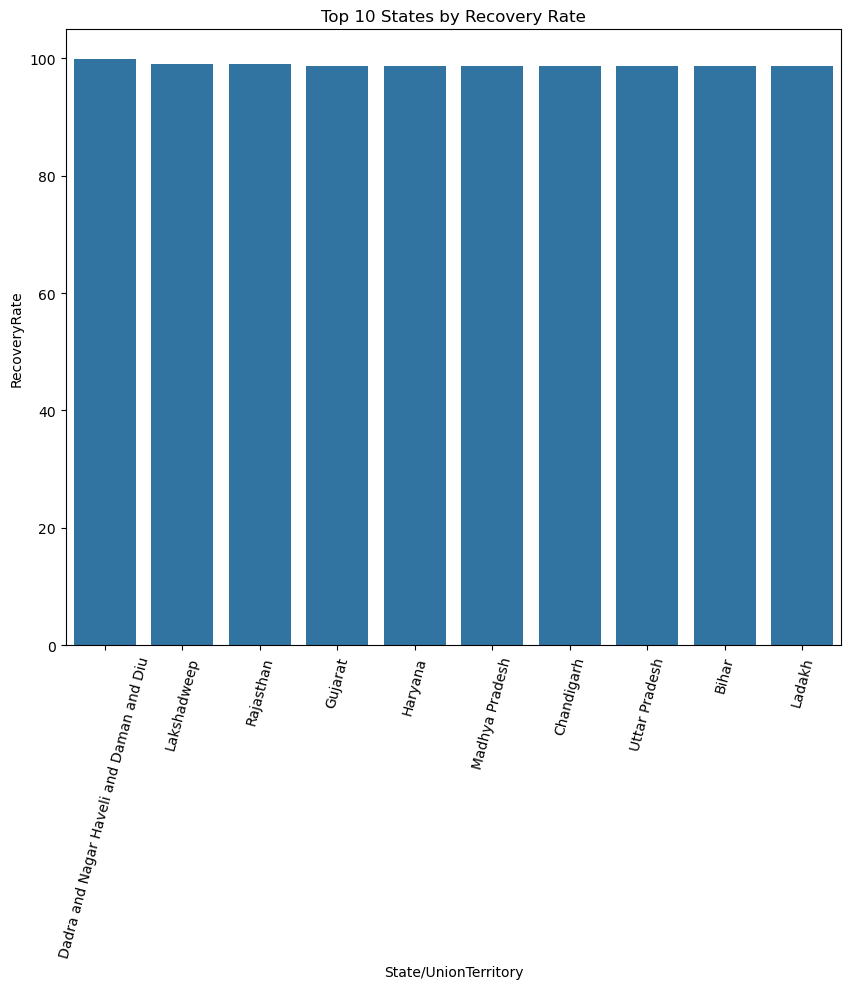

In [65]:
top_recovery = latest.sort_values(
    by='RecoveryRate',
    ascending=False
).head(10)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_recovery,
    x='State/UnionTerritory',
    y='RecoveryRate'
)

plt.xticks(rotation=75)
plt.title("Top 10 States by Recovery Rate")
plt.show()

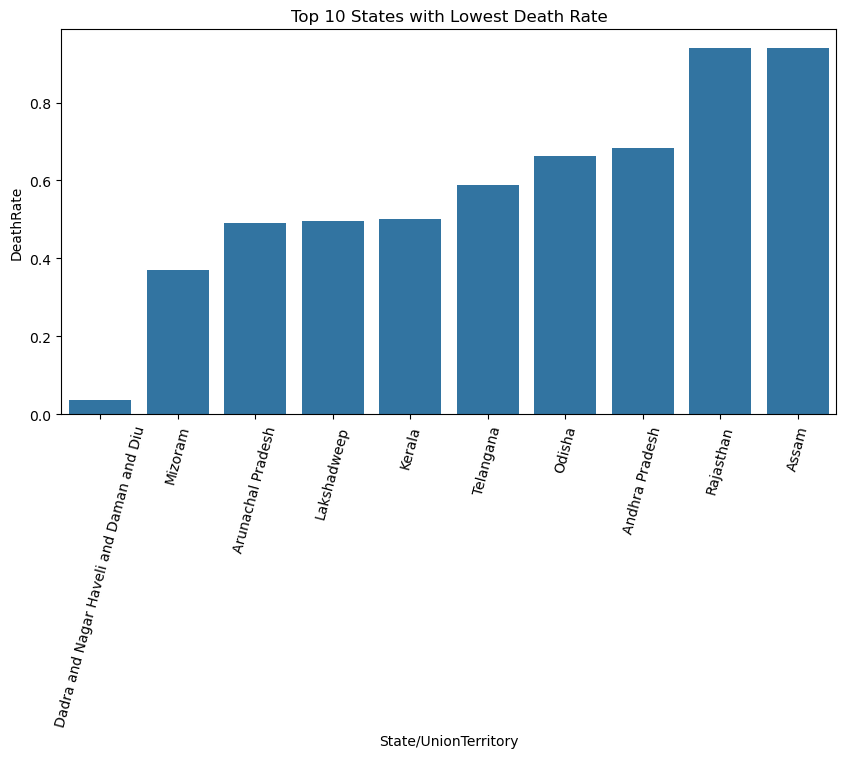

In [64]:
low_death = latest.sort_values(
    by='DeathRate'
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=low_death,
    x='State/UnionTerritory',
    y='DeathRate'
)

plt.xticks(rotation=75)
plt.title("Top 10 States with Lowest Death Rate")
plt.show()

In [66]:
latest_filtered = latest[
    latest['Confirmed'] > 10000
]

In [67]:
latest_filtered.sort_values(
    by='RecoveryRate',
    ascending=False
).head(10)

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed,ActiveCases,RecoveryRate,DeathRate,Year,Month,Quarter,DayOfWeek,DailyNewCases,DailyNewDeaths,DailyRecoveries
18081,18082,2021-08-11,8:00 AM,Dadra and Nagar Haveli and Daman and Diu,-,-,10646,4,10654,4,99.924911,0.037545,2021,8,3,Wednesday,1.0,0.0,3.0
18092,18093,2021-08-11,8:00 AM,Lakshadweep,-,-,10165,51,10263,47,99.045114,0.496931,2021,8,3,Wednesday,14.0,1.0,20.0
18102,18103,2021-08-11,8:00 AM,Rajasthan,-,-,944700,8954,953851,197,99.040626,0.938721,2021,8,3,Wednesday,11.0,0.0,30.0
18084,18085,2021-08-11,8:00 AM,Gujarat,-,-,814802,10077,825085,206,98.753704,1.221329,2021,8,3,Wednesday,21.0,0.0,24.0
18085,18086,2021-08-11,8:00 AM,Haryana,-,-,759790,9652,770114,672,98.659419,1.253321,2021,8,3,Wednesday,23.0,2.0,21.0
18093,18094,2021-08-11,8:00 AM,Madhya Pradesh,-,-,781330,10514,791980,136,98.655269,1.327559,2021,8,3,Wednesday,10.0,0.0,23.0
18079,18080,2021-08-11,8:00 AM,Chandigarh,-,-,61150,811,61992,31,98.641760,1.308233,2021,8,3,Wednesday,8.0,0.0,4.0
18108,18109,2021-08-11,8:00 AM,Uttar Pradesh,-,-,1685492,22775,1708812,545,98.635309,1.332797,2021,8,3,Wednesday,19.0,1.0,43.0
18078,18079,2021-08-11,8:00 AM,Bihar,-,-,715352,9646,725279,281,98.631285,1.329971,2021,8,3,Wednesday,44.0,0.0,49.0
18091,18092,2021-08-11,8:00 AM,Ladakh,-,-,20130,207,20411,74,98.623291,1.014159,2021,8,3,Wednesday,11.0,0.0,9.0


In [68]:
latest_filtered.sort_values(
    by='DeathRate'
).head(10)

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed,ActiveCases,RecoveryRate,DeathRate,Year,Month,Quarter,DayOfWeek,DailyNewCases,DailyNewDeaths,DailyRecoveries
18081,18082,2021-08-11,8:00 AM,Dadra and Nagar Haveli and Daman and Diu,-,-,10646,4,10654,4,99.924911,0.037545,2021,8,3,Wednesday,1.0,0.0,3.0
18097,18098,2021-08-11,8:00 AM,Mizoram,-,-,33722,171,46320,12427,72.802245,0.369171,2021,8,3,Wednesday,863.0,2.0,868.0
18076,18077,2021-08-11,8:00 AM,Arunachal Pradesh,-,-,47821,248,50605,2536,94.498567,0.490070,2021,8,3,Wednesday,233.0,2.0,301.0
18092,18093,2021-08-11,8:00 AM,Lakshadweep,-,-,10165,51,10263,47,99.045114,0.496931,2021,8,3,Wednesday,14.0,1.0,20.0
18090,18091,2021-08-11,8:00 AM,Kerala,-,-,3396184,18004,3586693,172505,94.688450,0.501967,2021,8,3,Wednesday,21119.0,152.0,18493.0
18105,18106,2021-08-11,8:00 AM,Telangana,-,-,638410,3831,650353,8112,98.163613,0.589065,2021,8,3,Wednesday,494.0,3.0,621.0
18099,18100,2021-08-11,8:00 AM,Odisha,-,-,972710,6565,988997,9722,98.353180,0.663804,2021,8,3,Wednesday,1041.0,64.0,1319.0
18075,18076,2021-08-11,8:00 AM,Andhra Pradesh,-,-,1952736,13564,1985182,18882,98.365591,0.683262,2021,8,3,Wednesday,1461.0,15.0,2113.0
18102,18103,2021-08-11,8:00 AM,Rajasthan,-,-,944700,8954,953851,197,99.040626,0.938721,2021,8,3,Wednesday,11.0,0.0,30.0
18077,18078,2021-08-11,8:00 AM,Assam,-,-,559684,5420,576149,11045,97.142232,0.940729,2021,8,3,Wednesday,929.0,16.0,964.0


In [70]:
latest = covid[covid['Date'] == latest_date].copy()

In [71]:
latest['ActiveCaseRatio'] = (
    (latest['Confirmed']
     - latest['Cured']
     - latest['Deaths'])
    / latest['Confirmed']
) * 100

In [72]:
latest.loc[:, 'ActiveCaseRatio'] = (
    (latest['Confirmed']
     - latest['Cured']
     - latest['Deaths'])
    / latest['Confirmed']
) * 100

In [73]:
latest[['State/UnionTerritory','ActiveCaseRatio']]\
.sort_values(by='ActiveCaseRatio', ascending=False)\
.head(10)

,State/UnionTerritory,ActiveCaseRatio
18097,Mizoram,26.828584
18103,Sikkim,9.161967
18095,Manipur,6.624677
18096,Meghalaya,6.345225
18076,Arunachal Pradesh,5.011363
18090,Kerala,4.809584
18098,Nagaland,4.769012
18106,Tripura,2.573766
18077,Assam,1.917039
18105,Telangana,1.247323


# Growth Rate Analysis

In [74]:
covid = covid.sort_values(
    ['State/UnionTerritory','Date']
)

covid['DailyNewCases'] = (
    covid.groupby(
        'State/UnionTerritory'
    )['Confirmed']
    .diff()
)

In [75]:
covid['GrowthRate'] = (
    covid['DailyNewCases']
    /
    covid['Confirmed'].shift(1)
) * 100

In [76]:
wave1 = covid[
    (covid['Date'] >= '2020-03-01') &
    (covid['Date'] <= '2021-02-28')
]

In [77]:
wave2 = covid[
    (covid['Date'] >= '2021-03-01') &
    (covid['Date'] <= '2021-07-31')
]

In [78]:
wave1_growth = (
    wave1.groupby('State/UnionTerritory')
    ['DailyNewCases']
    .mean()
    .sort_values(ascending=False)
)

In [79]:
wave1_growth.head(10)

State/UnionTerritory
Maharashtra       6030.266854
Kerala            2893.550685
Karnataka         2670.587079
Andhra Pradesh    2520.674221
Tamil Nadu        2377.268156
Delhi             1760.581267
Uttar Pradesh     1671.526316
West Bengal       1656.844380
Odisha             965.911175
Chhattisgarh       902.942197
Name: DailyNewCases, dtype: float64

In [80]:
wave2_growth = (
    wave2.groupby('State/UnionTerritory')
    ['DailyNewCases']
    .mean()
    .sort_values(ascending=False)
)

In [81]:
wave2_growth.head(10)

State/UnionTerritory
Maharashtra       27124.045752
Kerala            15124.104575
Karnataka         12760.830065
Tamil Nadu        11153.908497
Uttar Pradesh      7222.111111
Andhra Pradesh     7021.686275
West Bengal        6224.339869
Delhi              5209.901961
Chhattisgarh       4506.450980
Odisha             4173.764706
Name: DailyNewCases, dtype: float64

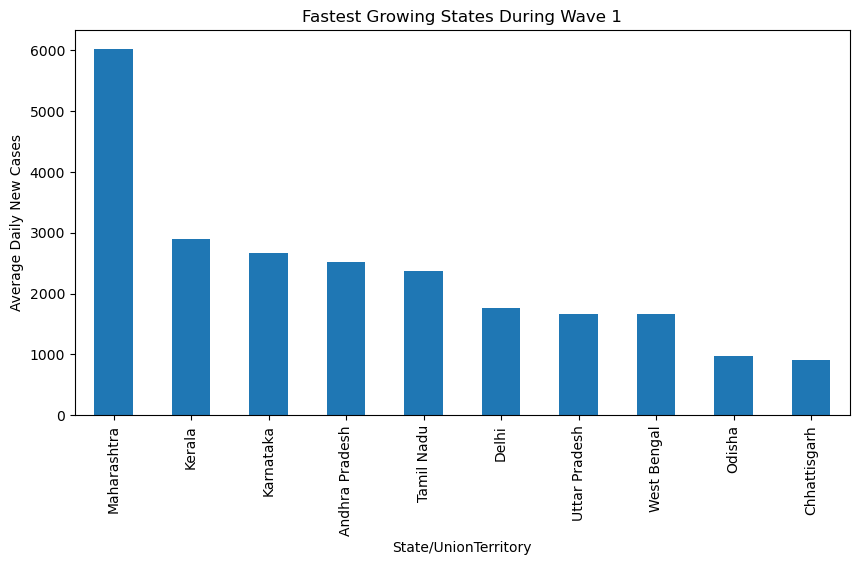

In [82]:
plt.figure(figsize=(10,5))

wave1_growth.head(10).plot(kind='bar')

plt.title("Fastest Growing States During Wave 1")
plt.ylabel("Average Daily New Cases")
plt.show()

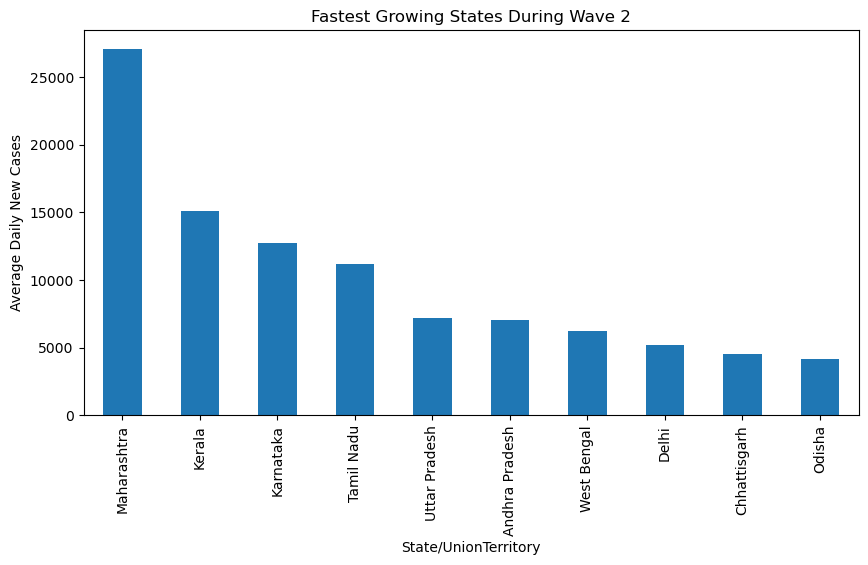

In [83]:
plt.figure(figsize=(10,5))

wave2_growth.head(10).plot(kind='bar')

plt.title("Fastest Growing States During Wave 2")
plt.ylabel("Average Daily New Cases")
plt.show()

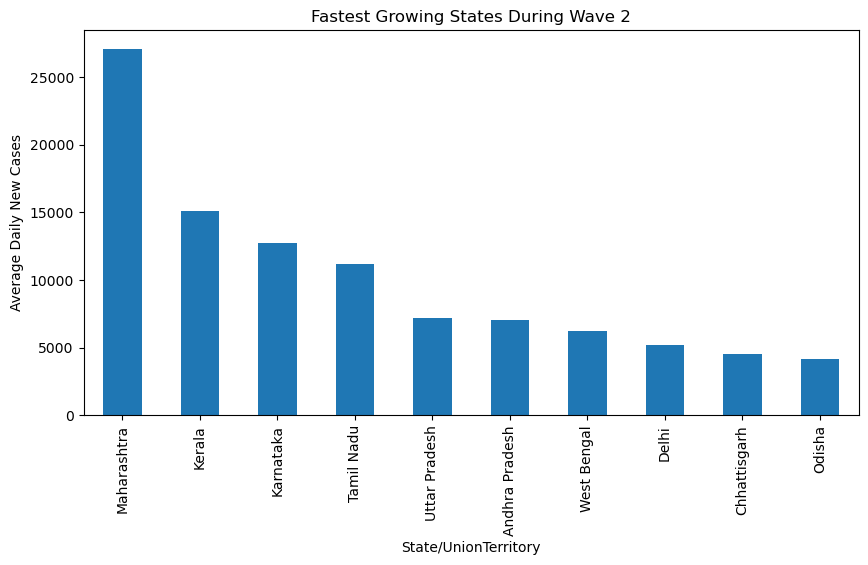

In [84]:
plt.figure(figsize=(10,5))

wave2_growth.head(10).plot(kind='bar')

plt.title("Fastest Growing States During Wave 2")
plt.ylabel("Average Daily New Cases")
plt.show()

# State Clustering

In [85]:
latest_date = covid['Date'].max()

latest = covid[covid['Date'] == latest_date].copy()

In [86]:
latest['ActiveCases'] = (
    latest['Confirmed']
    - latest['Cured']
    - latest['Deaths']
)

latest['RecoveryRate'] = (
    latest['Cured']
    / latest['Confirmed']
) * 100

latest['DeathRate'] = (
    latest['Deaths']
    / latest['Confirmed']
) * 100

latest['ActiveCaseRatio'] = (
    latest['ActiveCases']
    / latest['Confirmed']
) * 100

In [87]:
testing['PositivityRate'] = (
    testing['Positive']
    / testing['TotalSamples']
) * 100

In [88]:
latest_testing = (
    testing.sort_values('Date')
    .groupby('State')
    .tail(1)
)

In [89]:
latest_testing = latest_testing[
    ['State', 'PositivityRate']
]

### Merge Positivity Rate

In [90]:
latest.columns
latest_testing.columns

Index(['State', 'PositivityRate'], dtype='object')

In [91]:
risk_df = latest.merge(
    latest_testing,
    left_on='State/UnionTerritory',
    right_on='State',
    how='left'
)

In [92]:
risk_df['PositivityRate'] = (
    risk_df['PositivityRate']
    .fillna(
        risk_df['PositivityRate'].median()
    )
)

# Create Custom COVID Risk Score

In [93]:
risk_df['RiskScore'] = (
    risk_df['DeathRate'] * 0.5
    +
    risk_df['ActiveCaseRatio'] * 0.3
    +
    risk_df['PositivityRate'] * 0.2
)

In [94]:
risk_ranking = (
    risk_df[
        ['State/UnionTerritory',
         'RiskScore']
    ]
    .sort_values(
        by='RiskScore',
        ascending=False
    )
)

risk_ranking.head(15)

,State/UnionTerritory,RiskScore
23,Mizoram,8.233161
29,Sikkim,3.383896
21,Manipur,2.776597
22,Meghalaya,2.752799
24,Nagaland,2.445941
32,Tripura,2.237618
2,Arunachal Pradesh,1.748444
16,Kerala,1.693858
27,Punjab,1.384152
20,Maharashtra,1.382428


In [95]:
print(risk_ranking.head(10))

   State/UnionTerritory  RiskScore
23              Mizoram   8.233161
29               Sikkim   3.383896
21              Manipur   2.776597
22            Meghalaya   2.752799
24             Nagaland   2.445941
32              Tripura   2.237618
2     Arunachal Pradesh   1.748444
16               Kerala   1.693858
27               Punjab   1.384152
20          Maharashtra   1.382428


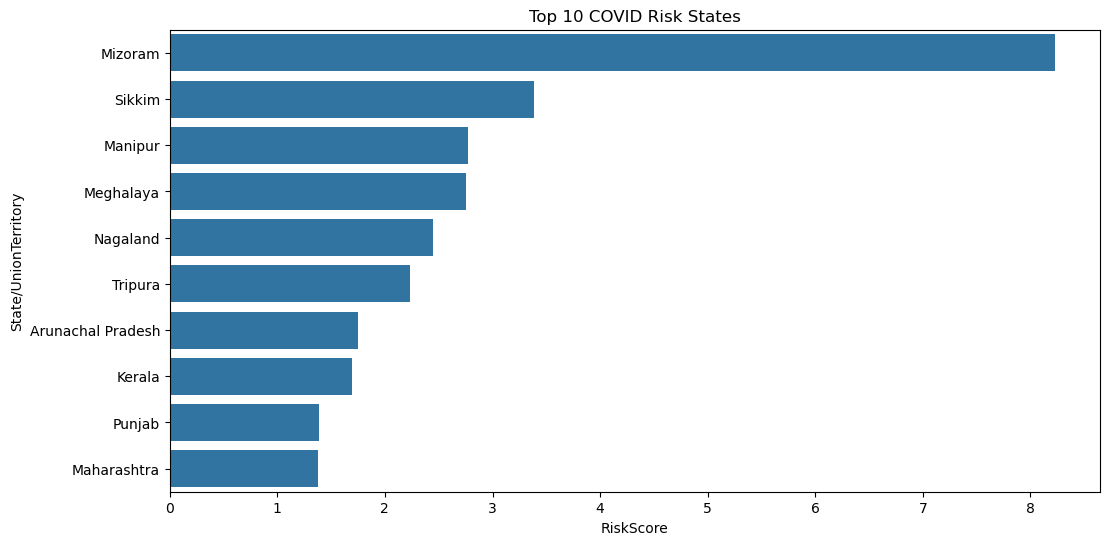

In [96]:
plt.figure(figsize=(12,6))

top10 = risk_ranking.head(10)

sns.barplot(
    data=top10,
    x='RiskScore',
    y='State/UnionTerritory'
)

plt.title("Top 10 COVID Risk States")
plt.show()

In [97]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [98]:
cluster_features = risk_df[
    [
        'Confirmed',
        'Deaths',
        'RecoveryRate',
        'DeathRate'
    ]
]

In [99]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    cluster_features
)

In [101]:
import warnings
warnings.filterwarnings('ignore')

In [102]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

risk_df['Cluster'] = kmeans.fit_predict(
    scaled_features
)

In [103]:
risk_df.groupby('Cluster')[
    [
        'Confirmed',
        'Deaths',
        'RecoveryRate',
        'DeathRate'
    ]
].mean()

,Confirmed,Deaths,RecoveryRate,DeathRate
Cluster,,,,
0,5.335444e+05,6631.870968,97.271793,1.286443
1,4.632000e+04,171.000000,72.802245,0.369171
2,3.862578e+06,55855.000000,96.831408,1.301218


In [104]:
cluster_mapping = {
    0: 'Low Risk',
    1: 'Moderate Risk',
    2: 'High Risk'
}

risk_df['RiskCategory'] = (
    risk_df['Cluster']
    .map(cluster_mapping)
)

In [105]:
risk_df[
    ['State/UnionTerritory',
     'RiskCategory']
].sort_values('RiskCategory')

,State/UnionTerritory,RiskCategory
15,Karnataka,High Risk
20,Maharashtra,High Risk
30,Tamil Nadu,High Risk
16,Kerala,High Risk
0,Andaman and Nicobar Islands,Low Risk
19,Madhya Pradesh,Low Risk
21,Manipur,Low Risk
22,Meghalaya,Low Risk
24,Nagaland,Low Risk
26,Puducherry,Low Risk


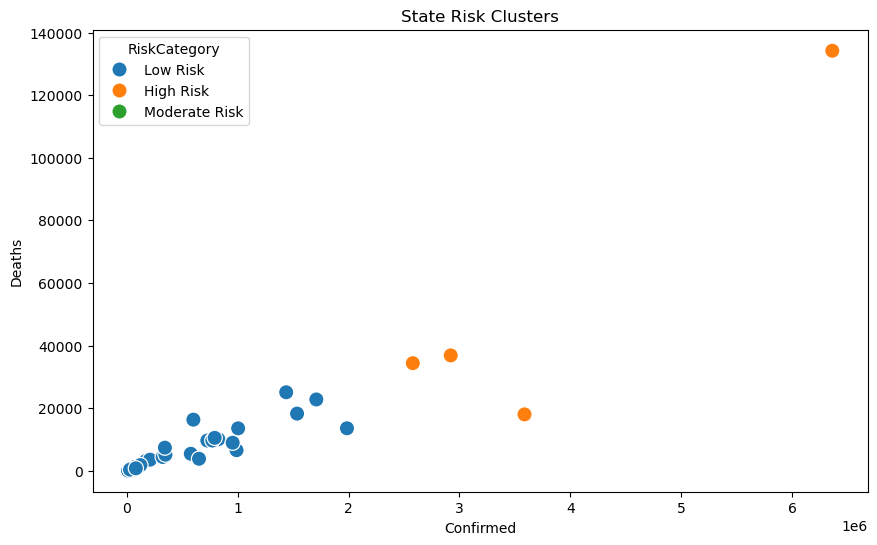

In [106]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=risk_df,
    x='Confirmed',
    y='Deaths',
    hue='RiskCategory',
    s=120
)

plt.title("State Risk Clusters")
plt.show()

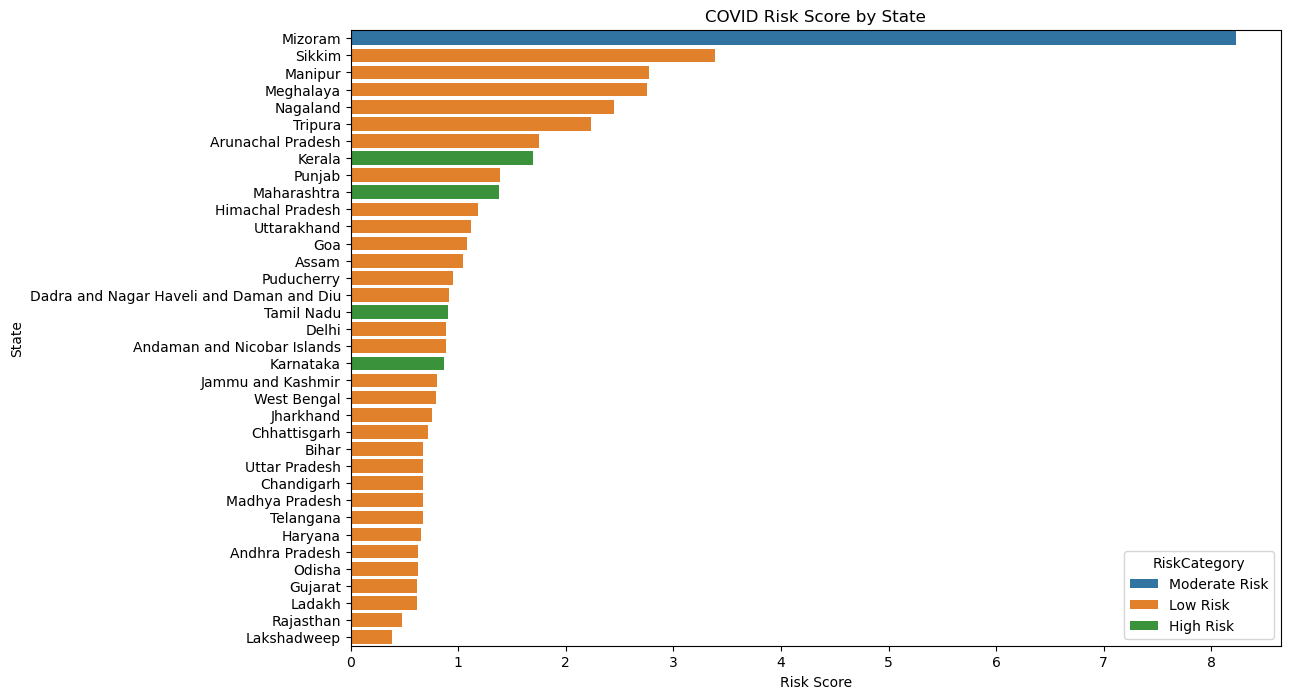

In [107]:
risk_sorted = risk_df.sort_values(
    by='RiskScore',
    ascending=False
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=risk_sorted,
    x='RiskScore',
    y='State/UnionTerritory',
    hue='RiskCategory'
)

plt.title("COVID Risk Score by State")
plt.xlabel("Risk Score")
plt.ylabel("State")
plt.show()

In [108]:
final_risk_table = risk_df[
    [
        'State/UnionTerritory',
        'Confirmed',
        'Deaths',
        'RecoveryRate',
        'DeathRate',
        'RiskScore',
        'RiskCategory'
    ]
]

final_risk_table.sort_values(
    by='RiskScore',
    ascending=False
).head(20)

,State/UnionTerritory,Confirmed,Deaths,RecoveryRate,DeathRate,RiskScore,RiskCategory
23,Mizoram,46320,171,72.802245,0.369171,8.233161,Moderate Risk
29,Sikkim,28018,356,89.567421,1.270612,3.383896,Low Risk
21,Manipur,105424,1664,91.796934,1.578388,2.776597,Low Risk
22,Meghalaya,69769,1185,91.956313,1.698462,2.752799,Low Risk
24,Nagaland,28811,585,93.200514,2.030474,2.445941,Low Risk
32,Tripura,80660,773,96.467890,0.958344,2.237618,Low Risk
2,Arunachal Pradesh,50605,248,94.498567,0.490070,1.748444,Low Risk
16,Kerala,3586693,18004,94.688450,0.501967,1.693858,High Risk
27,Punjab,599573,16322,97.201008,2.722271,1.384152,Low Risk
20,Maharashtra,6363442,134201,96.797865,2.108937,1.382428,High Risk
